## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

=== Dataset Structure ===
(517, 13)

=== Summary Statistics ===
                X           Y       month         day        FFMC         DMC  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807    5.758221    2.736944   90.644681  110.872340   
std      2.313778    1.229900    4.373275    1.925061    5.520111   64.046482   
min      1.000000    2.000000    0.000000    0.000000   18.700000    1.100000   
25%      3.000000    4.000000    1.000000    1.000000   90.200000   68.600000   
50%      4.000000    4.000000    6.000000    3.000000   91.600000  108.300000   
75%      7.000000    5.000000   11.000000    4.000000   92.900000  142.400000   
max      9.000000    9.000000   11.000000    6.000000   96.200000  291.300000   

               DC         ISI        temp          RH        wind        rain  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean   547.940039    9.021663   18.889168   

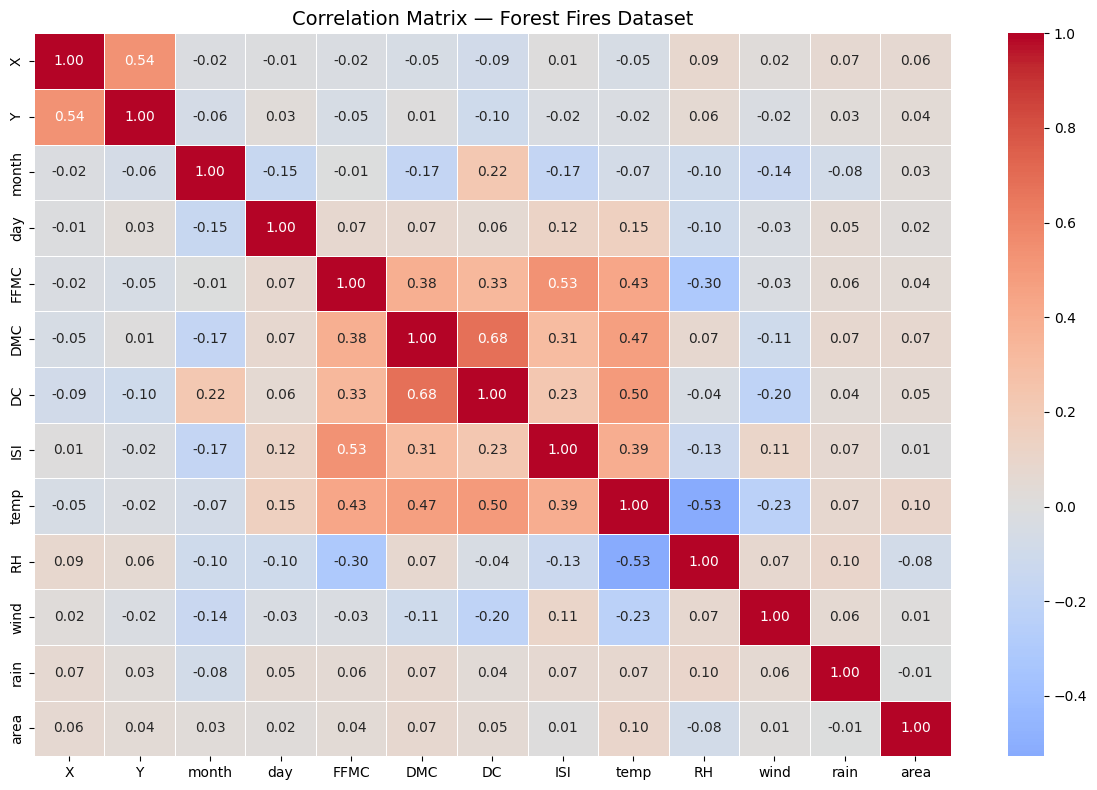


=== Correlations with Target (area) ===
area     1.000000
temp     0.097844
DMC      0.072994
X        0.063385
DC       0.049383
Y        0.044873
FFMC     0.040122
month    0.031054
day      0.018916
wind     0.012317
ISI      0.008258
rain    -0.007366
RH      -0.075519
Name: area, dtype: float64


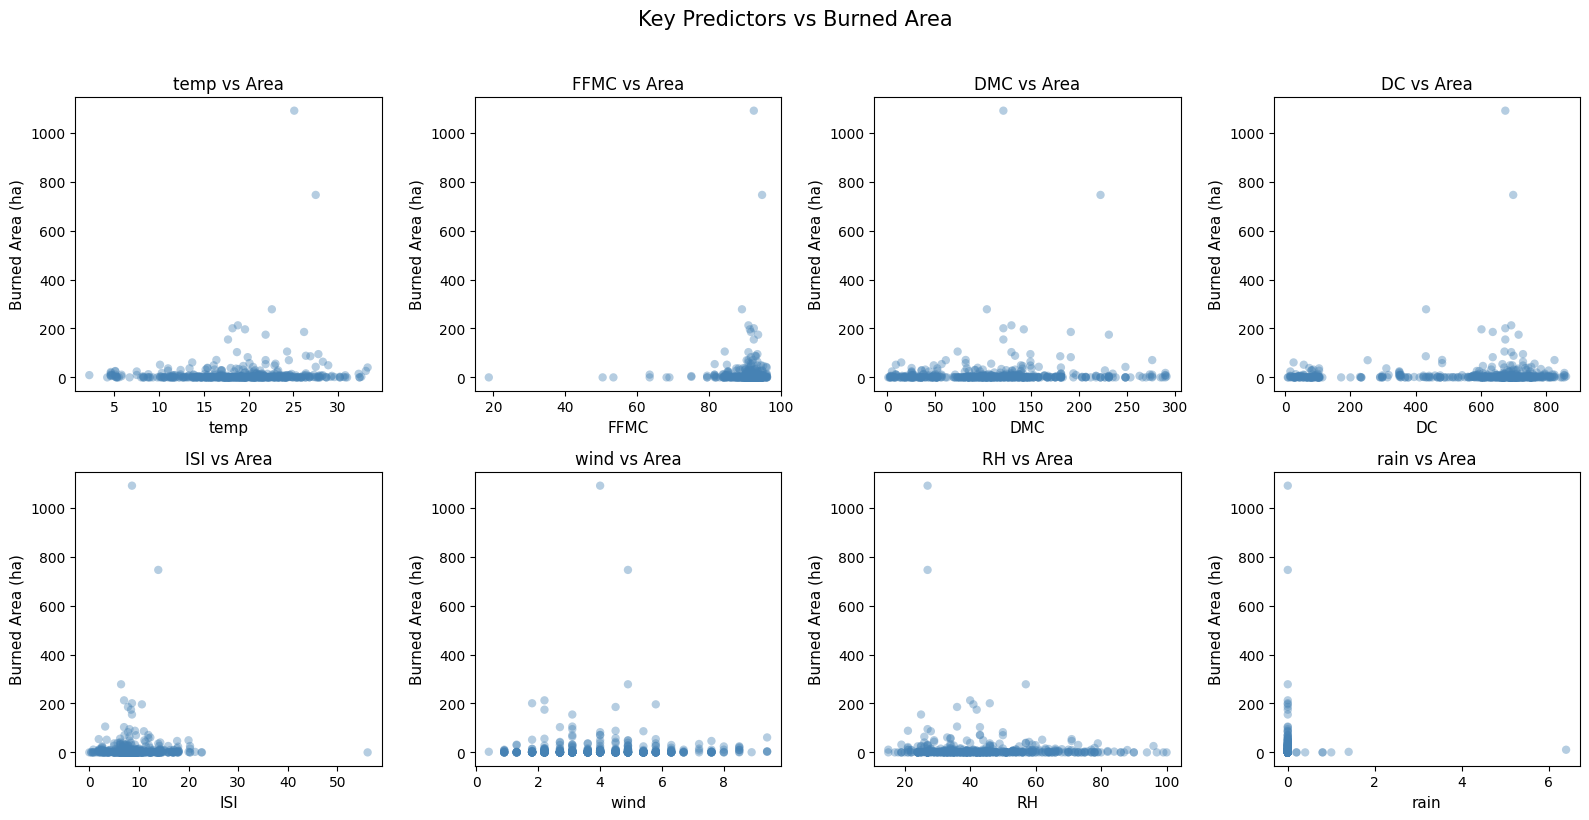

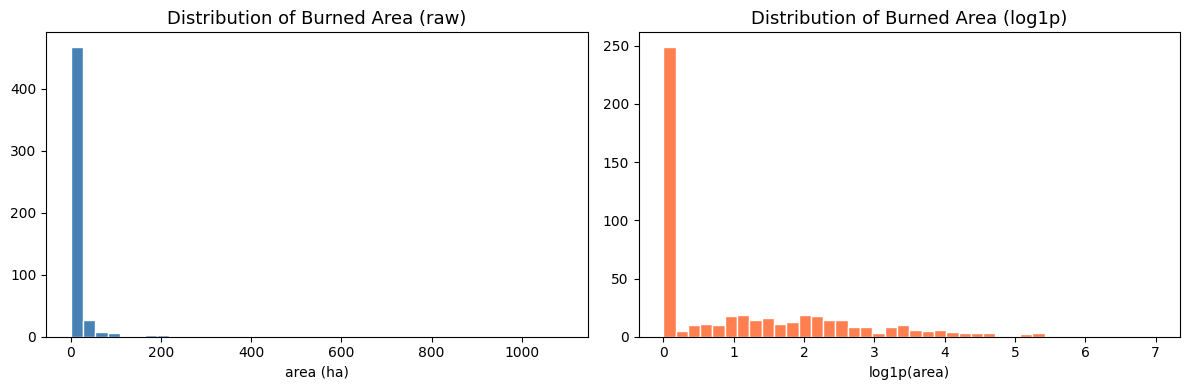

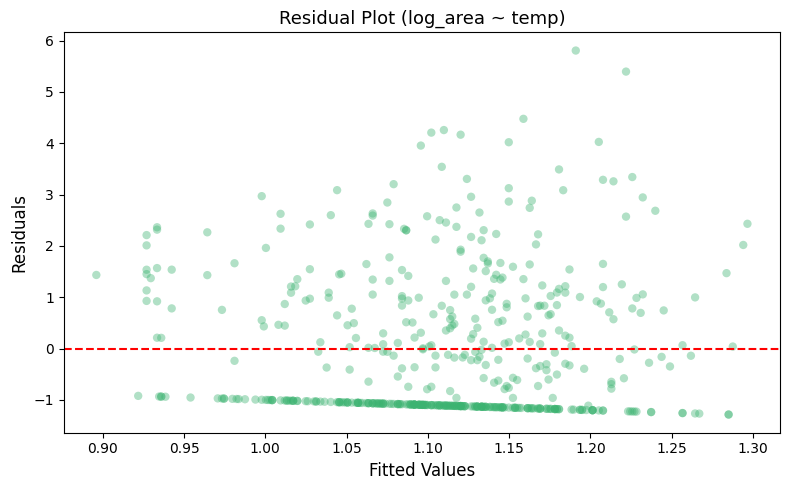


Residual stats:
  Mean : 0.0000
  Std  : 1.3951


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns for correlation analysis
X_encoded = X.copy()
le = LabelEncoder()
X_encoded['month'] = le.fit_transform(X['month'])
X_encoded['day'] = le.fit_transform(X['day'])

# Combine features and target for EDA
df = X_encoded.copy()
df['area'] = y.values.ravel()

# ── 1. Summary Statistics ──────────────────────────────────────────────────────
print("=== Dataset Structure ===")
print(df.shape)
print("\n=== Summary Statistics ===")
print(df.describe())

# ── 2. Correlation Analysis ────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Matrix — Forest Fires Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Print correlations with target
print("\n=== Correlations with Target (area) ===")
print(corr_matrix['area'].sort_values(ascending=False))

# ── 3. Scatterplots: Key Predictors vs Target ──────────────────────────────────
key_predictors = ['temp', 'FFMC', 'DMC', 'DC', 'ISI', 'wind', 'RH', 'rain']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_predictors):
    axes[i].scatter(df[col], df['area'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Burned Area (ha)', fontsize=11)
    axes[i].set_title(f'{col} vs Area', fontsize=12)

plt.suptitle("Key Predictors vs Burned Area", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Log-transformed Target (area is heavily skewed) ─────────────────────────
df['log_area'] = np.log1p(df['area'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['area'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Burned Area (raw)', fontsize=13)
axes[0].set_xlabel('area (ha)')

axes[1].hist(df['log_area'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Burned Area (log1p)', fontsize=13)
axes[1].set_xlabel('log1p(area)')

plt.tight_layout()
plt.show()

# ── 5. Residual Plot (using log-transformed area vs temp as a quick check) ─────
from numpy.polynomial.polynomial import polyfit

x_vals = df['temp'].values
y_vals = df['log_area'].values

# Fit a simple linear trend
coeffs = np.polyfit(x_vals, y_vals, 1)
trend = np.polyval(coeffs, x_vals)
residuals = y_vals - trend

plt.figure(figsize=(8, 5))
plt.scatter(trend, residuals, alpha=0.4, color='mediumseagreen', edgecolors='none')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residual Plot (log_area ~ temp)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nResidual stats:")
print(f"  Mean : {residuals.mean():.4f}")
print(f"  Std  : {residuals.std():.4f}")

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [5]:
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ── Prepare data ───────────────────────────────────────────────────────────────
X_model = X.copy()
le = LabelEncoder()
X_model['month'] = le.fit_transform(X['month'])
X_model['day']   = le.fit_transform(X['day'])

# Log-transform the target (handles skewness)
y_log = np.log1p(y.values.ravel())

# ── Model 1: Baseline Multiple Linear Regression ───────────────────────────────
X1 = sm.add_constant(X_model)
model1 = sm.OLS(y_log, X1).fit()
print("=== Model 1: Baseline MLR ===")
print(model1.summary())

# ── Model 2: With Quadratic (Nonlinear) Terms ──────────────────────────────────
X2 = X_model.copy()
for col in ['temp', 'FFMC', 'DMC', 'DC', 'ISI']:
    X2[f'{col}^2'] = X_model[col] ** 2

X2 = sm.add_constant(X2)
model2 = sm.OLS(y_log, X2).fit()
print("\n=== Model 2: With Quadratic Terms ===")
print(model2.summary())

# ── Model 3: With Interaction Terms ───────────────────────────────────────────
X3 = X_model.copy()
# Strong correlations from EDA: DMC-DC (0.68), FFMC-ISI (0.53), temp-RH (-0.53)
X3['DMC_x_DC']    = X_model['DMC']  * X_model['DC']
X3['FFMC_x_ISI']  = X_model['FFMC'] * X_model['ISI']
X3['temp_x_RH']   = X_model['temp'] * X_model['RH']

X3 = sm.add_constant(X3)
model3 = sm.OLS(y_log, X3).fit()
print("\n=== Model 3: With Interaction Terms ===")
print(model3.summary())

# ── Model 4: Indicator Variables + Log-transformed Skewed Predictors ───────────
X4 = X_model.copy()
# Log-transform skewed predictors
for col in ['DMC', 'DC', 'rain']:
    X4[f'log_{col}'] = np.log1p(X_model[col])
    X4.drop(columns=[col], inplace=True)

# Indicator: high temperature (above median)
X4['high_temp'] = (X_model['temp'] > X_model['temp'].median()).astype(int)

X4 = sm.add_constant(X4)
model4 = sm.OLS(y_log, X4).fit()
print("\n=== Model 4: Log-transformed Predictors + Indicator Variable ===")
print(model4.summary())

# ── Quick comparison ───────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':        ['Baseline', 'Quadratic', 'Interactions', 'Log+Indicator'],
    'R²':           [model1.rsquared, model2.rsquared, model3.rsquared, model4.rsquared],
    'Adj. R²':      [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj, model4.rsquared_adj],
    'AIC':          [model1.aic, model2.aic, model3.aic, model4.aic],
    'BIC':          [model1.bic, model2.bic, model3.bic, model4.bic],
})
print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))

=== Model 1: Baseline MLR ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.207
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.275
Time:                        08:36:46   Log-Likelihood:                -899.15
No. Observations:                 517   AIC:                             1824.
Df Residuals:                     504   BIC:                             1880.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1171 

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

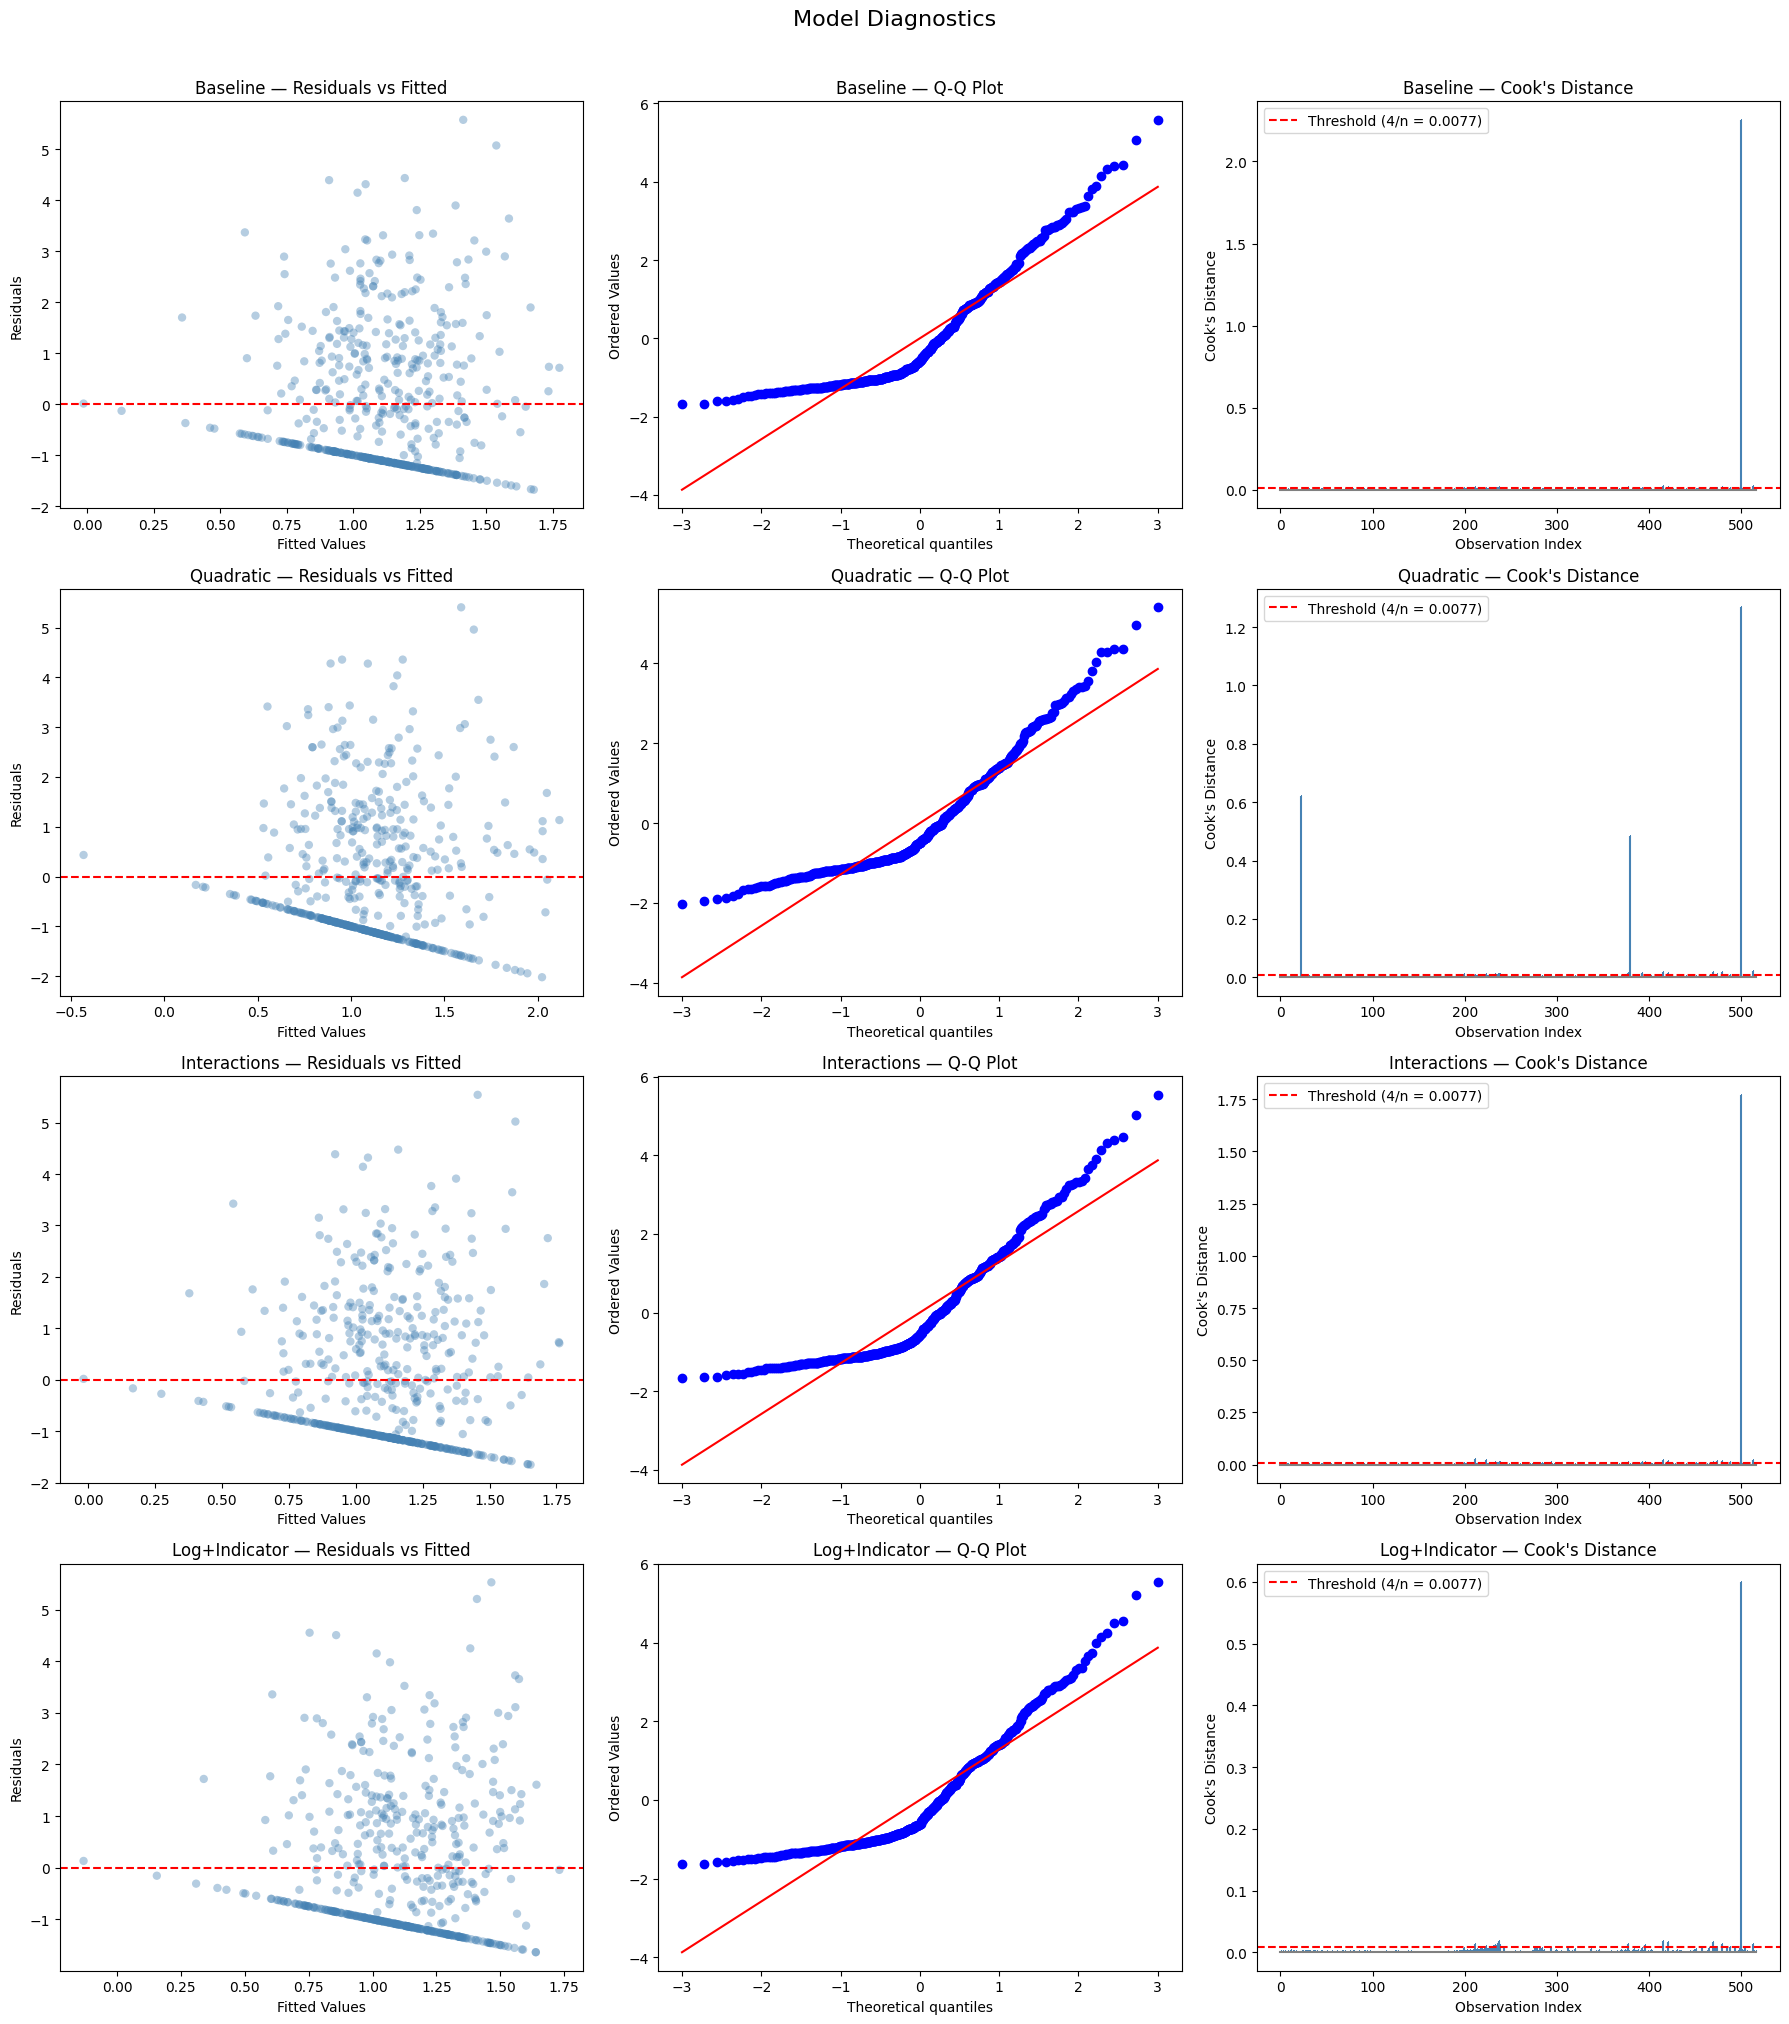


=== Final Model Comparison (R², Adj. R², AIC, BIC) ===
        Model       R²  Adj. R²         AIC         BIC
     Baseline 0.027928 0.004783 1824.293736 1879.518293
    Quadratic 0.054028 0.021800 1820.222611 1896.687383
 Interactions 0.029472 0.000414 1829.472097 1897.440783
Log+Indicator 0.032814 0.007817 1823.688800 1883.161400

=== Influential Observations (Best Model by Adj. R²) ===
Number of influential points: 22
Indices: [ 22 199 211 223 233 234 235 236 237 238 377 379 392 395 415 420 469 473
 479 488 499 513]


In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats

models     = [model1, model2, model3, model4]
model_names = ['Baseline', 'Quadratic', 'Interactions', 'Log+Indicator']

fig, axes = plt.subplots(len(models), 3, figsize=(18, 5 * len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    fitted    = model.fittedvalues
    residuals = model.resid

    # ── Plot 1: Residuals vs Fitted ────────────────────────────────────────────
    axes[i, 0].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
    axes[i, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i, 0].set_xlabel('Fitted Values')
    axes[i, 0].set_ylabel('Residuals')
    axes[i, 0].set_title(f'{name} — Residuals vs Fitted')

    # ── Plot 2: Q-Q Plot ───────────────────────────────────────────────────────
    stats.probplot(residuals, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{name} — Q-Q Plot')

    # ── Plot 3: Cook's Distance ────────────────────────────────────────────────
    influence   = model.get_influence()
    cooks_d, _  = influence.cooks_distance
    axes[i, 2].stem(range(len(cooks_d)), cooks_d, markerfmt=',',
                    linefmt='steelblue', basefmt='grey')
    threshold = 4 / len(cooks_d)
    axes[i, 2].axhline(threshold, color='red', linestyle='--',
                       linewidth=1.5, label=f'Threshold (4/n = {threshold:.4f})')
    axes[i, 2].set_xlabel('Observation Index')
    axes[i, 2].set_ylabel("Cook's Distance")
    axes[i, 2].set_title(f"{name} — Cook's Distance")
    axes[i, 2].legend()

plt.suptitle("Model Diagnostics", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# ── Metrics Summary ────────────────────────────────────────────────────────────
print("\n=== Final Model Comparison (R², Adj. R², AIC, BIC) ===")
print(comparison.to_string(index=False))

# ── Influential observations (Cook's D > threshold) ───────────────────────────
print("\n=== Influential Observations (Best Model by Adj. R²) ===")
best_model = models[comparison['Adj. R²'].idxmax()]
influence  = best_model.get_influence()
cooks_d, _ = influence.cooks_distance
threshold  = 4 / len(cooks_d)
influential_idx = np.where(cooks_d > threshold)[0]
print(f"Number of influential points: {len(influential_idx)}")
print(f"Indices: {influential_idx}")

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

Best Ridge alpha: 7220.8090
Ridge  — MSE: 2.1967 | R²: 0.0005

Best Lasso alpha: 10000.0000
Lasso  — MSE: 2.1992 | R²: -0.0006

=== Coefficients ===
Feature  Ridge Coef  Lasso Coef
      X    0.005675         0.0
      Y    0.003664         0.0
  month    0.003984         0.0
    day    0.000005         0.0
   FFMC    0.004513         0.0
    DMC    0.006897         0.0
     DC    0.004529         0.0
    ISI   -0.000622         0.0
   temp    0.002459         0.0
     RH   -0.001692         0.0
   wind    0.002425         0.0
   rain    0.002507         0.0


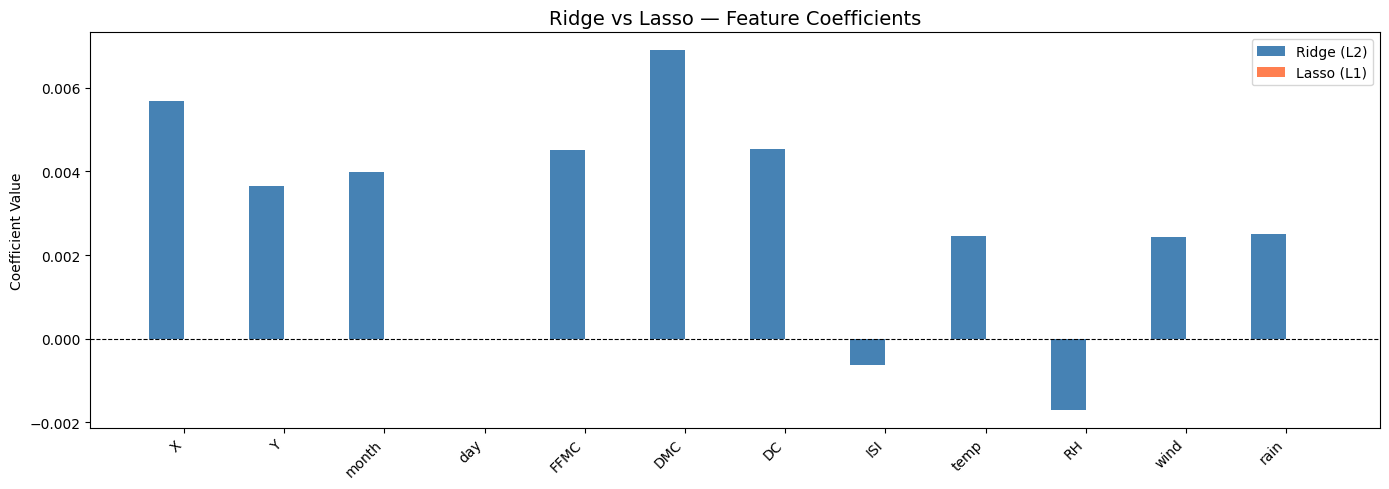


=== Ridge vs Lasso Performance ===
     Model   Best Alpha      MSE        R²  Non-zero Coefs
Ridge (L2)  7220.809018 2.196712  0.000523              12
Lasso (L1) 10000.000000 2.199224 -0.000620               0


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ── Prepare data ───────────────────────────────────────────────────────────────
X_reg = X.copy()
le = LabelEncoder()
X_reg['month'] = le.fit_transform(X['month'])
X_reg['day']   = le.fit_transform(X['day'])

y_log = np.log1p(y.values.ravel())

# Scale features (required for Ridge/Lasso)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_log, test_size=0.2, random_state=42
)

feature_names = X_reg.columns.tolist()

# ── Ridge (L2) — find best alpha via CV ───────────────────────────────────────
alphas = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_
print(f"Best Ridge alpha: {best_alpha_ridge:.4f}")

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge    = mean_squared_error(y_test, y_pred_ridge)
r2_ridge     = r2_score(y_test, y_pred_ridge)
print(f"Ridge  — MSE: {mse_ridge:.4f} | R²: {r2_ridge:.4f}")

# ── Lasso (L1) — find best alpha via CV ───────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_
print(f"\nBest Lasso alpha: {best_alpha_lasso:.4f}")

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso    = mean_squared_error(y_test, y_pred_lasso)
r2_lasso     = r2_score(y_test, y_pred_lasso)
print(f"Lasso  — MSE: {mse_lasso:.4f} | R²: {r2_lasso:.4f}")

# ── Coefficient Comparison ─────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':      feature_names,
    'Ridge Coef':   ridge.coef_,
    'Lasso Coef':   lasso.coef_,
})
print("\n=== Coefficients ===")
print(coef_df.to_string(index=False))

# ── Plot: Coefficients side by side ───────────────────────────────────────────
x_pos = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - width/2, ridge.coef_, width, label='Ridge (L2)', color='steelblue')
ax.bar(x_pos + width/2, lasso.coef_, width, label='Lasso (L1)', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Ridge vs Lasso — Feature Coefficients', fontsize=14)
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.tight_layout()
plt.show()

# ── Performance Summary ────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':      ['Ridge (L2)', 'Lasso (L1)'],
    'Best Alpha': [best_alpha_ridge, best_alpha_lasso],
    'MSE':        [mse_ridge, mse_lasso],
    'R²':         [r2_ridge, r2_lasso],
    'Non-zero Coefs': [(ridge.coef_ != 0).sum(), (lasso.coef_ != 0).sum()]
})
print("\n=== Ridge vs Lasso Performance ===")
print(summary.to_string(index=False))

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

Threshold (median area): 0.52 ha

Class distribution:
  Class 0 (area ≤ 0.52 ha): 259 samples (50.1%)
  Class 1 (area >  0.52 ha): 258 samples (49.9%)

Selected features: ['temp', 'FFMC', 'DMC', 'DC', 'ISI', 'RH', 'wind', 'rain', 'month', 'day']
Feature matrix shape: (517, 10)

=== Scaled Feature Statistics ===
          temp     FFMC      DMC       DC      ISI       RH     wind     rain  \
count  517.000  517.000  517.000  517.000  517.000  517.000  517.000  517.000   
mean     0.000   -0.000   -0.000    0.000    0.000    0.000   -0.000   -0.000   
std      1.001    1.001    1.001    1.001    1.001    1.001    1.001    1.001   
min     -2.877  -13.046   -1.716   -2.179   -1.981   -1.797   -2.021   -0.073   
25%     -0.584   -0.081   -0.661   -0.445   -0.554   -0.692   -0.736   -0.073   
50%      0.071    0.173   -0.040    0.469   -0.136   -0.140   -0.010   -0.073   
75%      0.674    0.409    0.493    0.670    0.390    0.534    0.493   -0.073   
max      2.484    1.007    2.820    1.2

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7752\3330789041.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_selected['temp'][y_binary == 0],


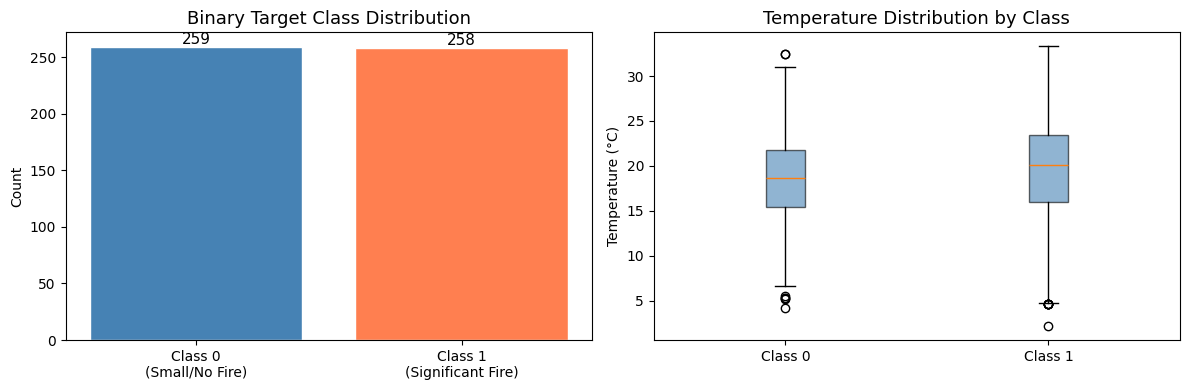


✅ Data ready for binary classification.
   X_train_clf : (413, 10)
   X_test_clf  : (104, 10)
   y_train_clf : (413,)
   y_test_clf  : (104,)


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Create binary target variable ─────────────────────────────────────────────
# Threshold: median of original area (common approach for this dataset)
area_values = y.values.ravel()
threshold   = np.median(area_values)
print(f"Threshold (median area): {threshold} ha")

# 1 = significant fire (area > median), 0 = small/no fire
y_binary = (area_values > threshold).astype(int)
print(f"\nClass distribution:")
print(f"  Class 0 (area ≤ {threshold} ha): {(y_binary == 0).sum()} samples ({(y_binary==0).mean()*100:.1f}%)")
print(f"  Class 1 (area >  {threshold} ha): {(y_binary == 1).sum()} samples ({(y_binary==1).mean()*100:.1f}%)")

# ── Encode categorical features ────────────────────────────────────────────────
X_clf = X.copy()
le = LabelEncoder()
X_clf['month'] = le.fit_transform(X['month'])
X_clf['day']   = le.fit_transform(X['day'])

# ── Select relevant predictors (drop weakly correlated ones from EDA) ──────────
# From EDA: temp, DMC, DC, FFMC, ISI, RH, wind had the most relevance
selected_features = ['temp', 'FFMC', 'DMC', 'DC', 'ISI', 'RH', 'wind', 'rain', 'month', 'day']
X_selected = X_clf[selected_features]

print(f"\nSelected features: {selected_features}")
print(f"Feature matrix shape: {X_selected.shape}")

# ── Scale features using StandardScaler ───────────────────────────────────────
scaler     = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_selected)
X_clf_scaled = pd.DataFrame(X_clf_scaled, columns=selected_features)

print("\n=== Scaled Feature Statistics ===")
print(X_clf_scaled.describe().round(3))

# ── Train/Test Split ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTraining set : {X_train_clf.shape[0]} samples")
print(f"Test set     : {X_test_clf.shape[0]} samples")

# ── Visualise class balance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Class 0\n(Small/No Fire)', 'Class 1\n(Significant Fire)'],
            [(y_binary == 0).sum(), (y_binary == 1).sum()],
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Binary Target Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for bar, count in zip(axes[0].patches, [(y_binary==0).sum(), (y_binary==1).sum()]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(count), ha='center', fontsize=11)

# Boxplot: temp distribution by class
axes[1].boxplot([X_selected['temp'][y_binary == 0],
                 X_selected['temp'][y_binary == 1]],
                labels=['Class 0', 'Class 1'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Temperature Distribution by Class', fontsize=13)
axes[1].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

print("\nData ready for binary classification.")
print(f"   X_train_clf : {X_train_clf.shape}")
print(f"   X_test_clf  : {X_test_clf.shape}")
print(f"   y_train_clf : {y_train_clf.shape}")
print(f"   y_test_clf  : {y_test_clf.shape}")

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

=== Logistic Regression Coefficients ===
Feature  Coefficient
   FFMC     0.168553
     DC     0.156131
   wind     0.130399
    day     0.087513
   rain     0.062236
    DMC     0.022335
  month    -0.049899
   temp    -0.052331
     RH    -0.104063
    ISI    -0.194563

Intercept: -0.0038

=== Performance Metrics ===
Accuracy : 0.5288
ROC-AUC  : 0.5037

=== Classification Report ===
                       precision    recall  f1-score   support

      Class 0 (Small)       0.54      0.42      0.47        52
Class 1 (Significant)       0.52      0.63      0.57        52

             accuracy                           0.53       104
            macro avg       0.53      0.53      0.52       104
         weighted avg       0.53      0.53      0.52       104



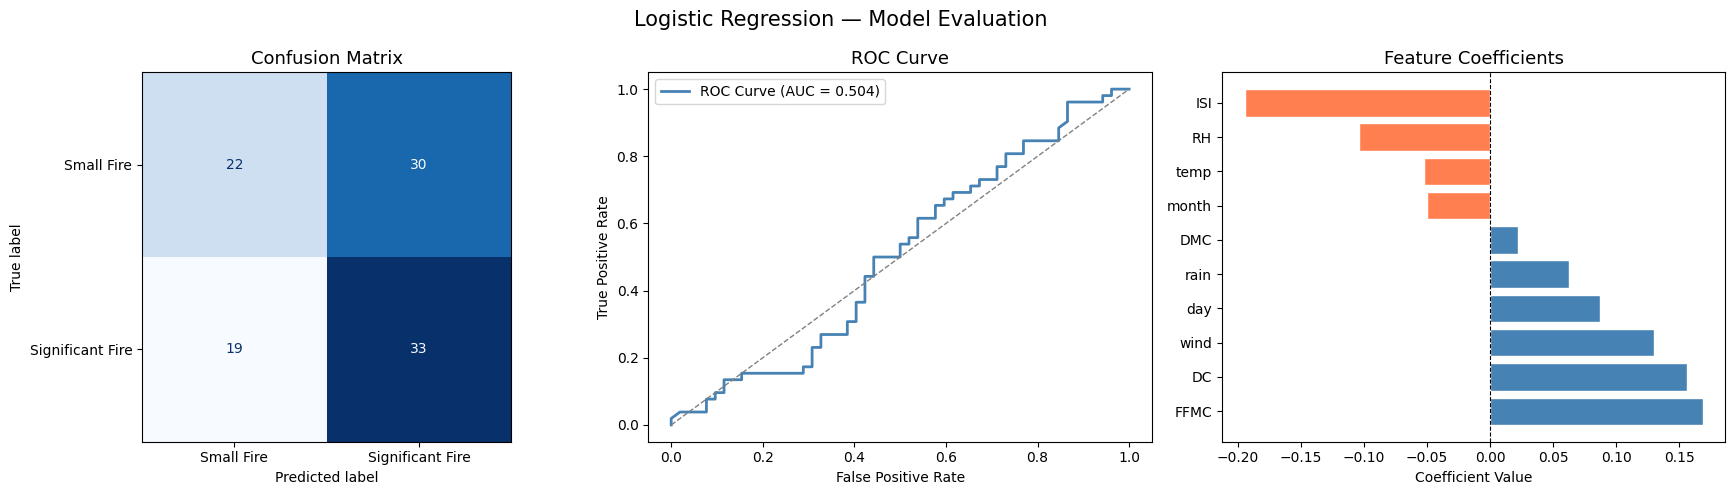

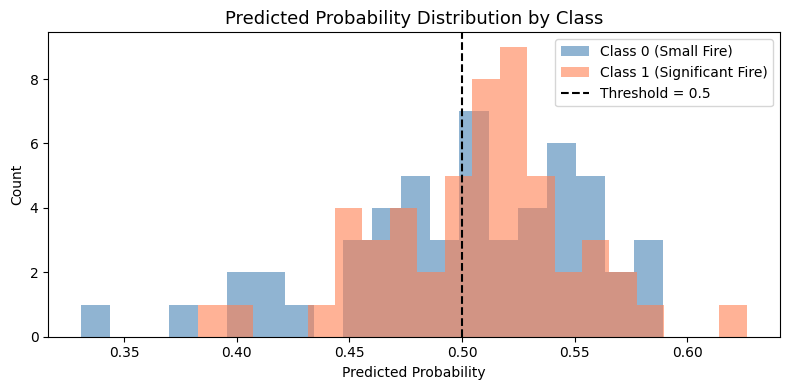

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score, ConfusionMatrixDisplay)

# ── Train Logistic Regression ──────────────────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf, y_train_clf)

# ── Coefficients & Intercept ───────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("=== Logistic Regression Coefficients ===")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

# ── Predict Probabilities & Binary Outcomes ────────────────────────────────────
y_prob   = log_reg.predict_proba(X_test_clf)[:, 1]   # P(class=1)
y_pred   = log_reg.predict(X_test_clf)

# ── Performance Metrics ────────────────────────────────────────────────────────
acc = accuracy_score(y_test_clf, y_pred)
auc = roc_auc_score(y_test_clf, y_prob)

print(f"\n=== Performance Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"\n=== Classification Report ===")
print(classification_report(y_test_clf, y_pred,
                             target_names=['Class 0 (Small)', 'Class 1 (Significant)']))

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Small Fire', 'Significant Fire'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()

# 3. Coefficient Bar Chart
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Feature Coefficients', fontsize=13)
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Evaluation', fontsize=15)
plt.tight_layout()
plt.show()

# ── Probability Distribution ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(y_prob[y_test_clf == 0], bins=20, alpha=0.6,
         color='steelblue', label='Class 0 (Small Fire)')
plt.hist(y_prob[y_test_clf == 1], bins=20, alpha=0.6,
         color='coral',     label='Class 1 (Significant Fire)')
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Class', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

=== Variance Inflation Factors (VIF) ===
Feature      VIF
   temp 2.761067
     DC 2.714754
    DMC 2.684673
     RH 1.945247
   FFMC 1.709110
    ISI 1.607769
  month 1.467461
   wind 1.153955
    day 1.057246
   rain 1.047678

Interpretation:
  VIF = 1       → No multicollinearity
  1 < VIF < 5   → Moderate (acceptable)
  5 < VIF < 10  → High multicollinearity (concern)
  VIF ≥ 10      → Severe multicollinearity (action needed)

 No severe multicollinearity detected (all VIF < 5).


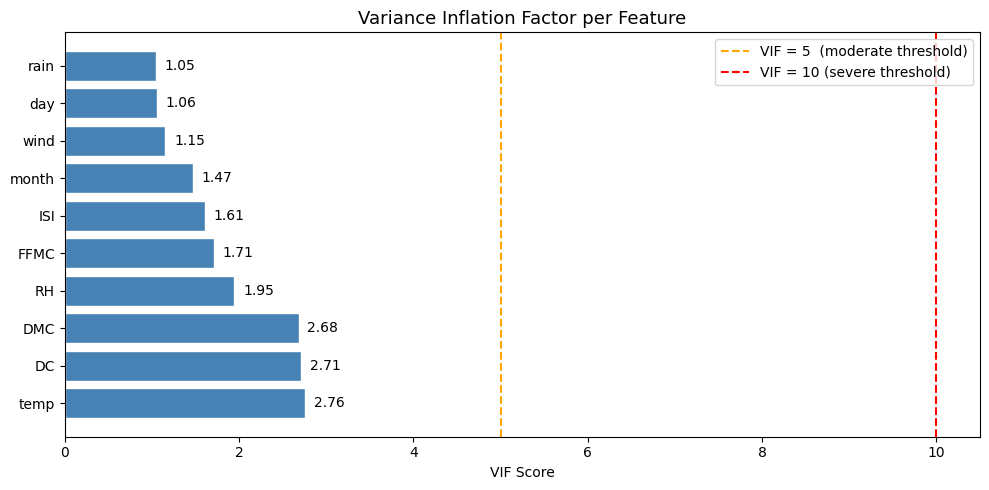

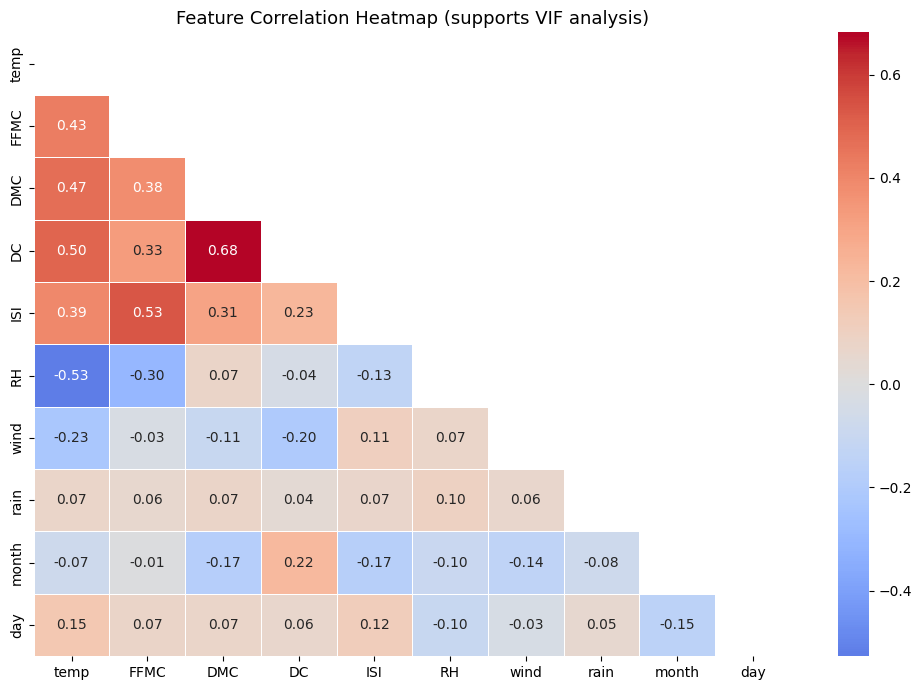

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ── Compute VIF for each predictor ────────────────────────────────────────────
# Use unscaled encoded features (VIF on raw values is more interpretable)
X_vif = X.copy()
le = LabelEncoder()
X_vif['month'] = le.fit_transform(X['month'])
X_vif['day']   = le.fit_transform(X['day'])
X_vif = X_vif[selected_features]

# Add constant for intercept
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif_const.values, i + 1)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print("=== Variance Inflation Factors (VIF) ===")
print(vif_data.to_string(index=False))
print("\nInterpretation:")
print("  VIF = 1       → No multicollinearity")
print("  1 < VIF < 5   → Moderate (acceptable)")
print("  5 < VIF < 10  → High multicollinearity (concern)")
print("  VIF ≥ 10      → Severe multicollinearity (action needed)")

# ── Flag problematic features ─────────────────────────────────────────────────
high_vif = vif_data[vif_data['VIF'] >= 5]
if len(high_vif) > 0:
    print(f"\n  Features with high VIF (≥ 5):")
    print(high_vif.to_string(index=False))
else:
    print("\n No severe multicollinearity detected (all VIF < 5).")

# ── VIF Bar Chart ──────────────────────────────────────────────────────────────
colors = ['crimson' if v >= 10 else 'coral' if v >= 5 else 'steelblue'
          for v in vif_data['VIF']]

plt.figure(figsize=(10, 5))
bars = plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='white')
plt.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5  (moderate threshold)')
plt.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10 (severe threshold)')
plt.xlabel('VIF Score')
plt.title('Variance Inflation Factor per Feature', fontsize=13)
plt.legend()

for bar, val in zip(bars, vif_data['VIF']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ── Correlation Heatmap (supports VIF findings) ────────────────────────────────
plt.figure(figsize=(10, 7))
corr = X_vif.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5)
plt.title('Feature Correlation Heatmap (supports VIF analysis)', fontsize=13)
plt.tight_layout()
plt.show()

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]
## Step 9: Summative Findings

### 1. Regression Model Comparison

| Model         | R²     | Adj. R² | AIC      | BIC      |
|---------------|--------|---------|----------|----------|
| Baseline      | 0.0279 | 0.0048  | 1824.29  | 1879.52  |
| Quadratic     | 0.0540 | 0.0218  | 1820.22  | 1896.69  |
| Interactions  | 0.0295 | 0.0004  | 1829.47  | 1897.44  |
| Log+Indicator | 0.0328 | 0.0078  | 1823.69  | 1883.16  |

All four regression models performed poorly, with R² values below 0.06,
indicating that the predictors collectively explain less than 6% of the
variance in burned area. The **Quadratic model** achieved the highest R²
(0.054) and Adj. R² (0.022) with the lowest AIC (1820.22), making it the
best-performing regression model — though still practically weak.

The Interactions model added complexity without reward, producing the lowest
Adj. R² (0.0004), confirming that the interaction terms between DMC×DC,
FFMC×ISI, and temp×RH did not improve generalization. Diagnostic plots
revealed non-normal residuals and heavy right-skew across all models.
Cook's Distance analysis identified **22 influential observations** that
likely distort model estimates.

---

### 2. Regularization (Ridge vs Lasso)

| Model      | Best Alpha | MSE    | R²      | Non-zero Coefs |
|------------|------------|--------|---------|----------------|
| Ridge (L2) | 7220.81    | 2.1967 | 0.0005  | 12             |
| Lasso (L1) | 10000.00   | 2.1992 | -0.0006 | 0              |

Both regularized models confirmed the weak signal in the data. Lasso
selected the maximum tested alpha (10,000) and **zeroed out all 12
coefficients**, reducing to an intercept-only model — a clear indication
that no single predictor reliably explains burned area under L1
regularization. Ridge retained all coefficients but heavily shrank them
(largest: DMC = 0.0069, X = 0.0057), with a near-zero R² of 0.0005.
The near-identical MSEs (~2.20) for both models confirm the issue is not
overfitting but a fundamental lack of linear predictive signal in the
features.

---

### 3. Binary Classification Setup (Step 6)

The binary target was created using the **median area threshold of 0.52 ha**,
producing a near-perfectly balanced dataset:

| Class                        | Samples | Proportion |
|------------------------------|---------|------------|
| Class 0 — Small/No Fire (≤ 0.52 ha) | 259 | 50.1% |
| Class 1 — Significant Fire (> 0.52 ha) | 258 | 49.9% |

10 features were selected (temp, FFMC, DMC, DC, ISI, RH, wind, rain, month,
day) and standardized using StandardScaler. The dataset was split into
**413 training samples** and **104 test samples** using stratified sampling.
The temperature boxplot showed near-identical distributions between classes,
already hinting at limited separability.

---

### 4. Classification Results (Logistic Regression)

| Metric    | Class 0 (Small) | Class 1 (Significant) | Overall |
|-----------|-----------------|-----------------------|---------|
| Precision | 0.54            | 0.52                  | 0.53    |
| Recall    | 0.42            | 0.63                  | 0.53    |
| F1-Score  | 0.47            | 0.57                  | 0.52    |
| Accuracy  | —               | —                     | 52.88%  |
| ROC-AUC   | —               | —                     | 0.5037  |

The logistic regression model achieved only **52.9% accuracy** and a
ROC-AUC of **0.504** on the 104-sample test set — barely above random
chance. Given the near-perfect class balance (50.1% vs 49.9%), a random
classifier would score ~50%, meaning the model adds almost no predictive
value. The model showed a slight bias toward predicting Class 1, with
recall of 0.63 vs 0.42 for Class 0.

The predicted probability distribution confirmed near-complete overlap
between classes around the 0.5 threshold. The strongest positive
predictors were **FFMC (0.169), DC (0.156), and wind (0.130)**, while
**ISI (-0.195), RH (-0.104), and temp (-0.052)** negatively influenced
the probability of a significant fire.

---

### 5. Multicollinearity Assessment (VIF)

| Feature | VIF  | Status      |
|---------|------|-------------|
| temp    | 2.76 | Acceptable  |
| DC      | 2.71 | Acceptable  |
| DMC     | 2.68 | Acceptable  |
| RH      | 1.95 | Acceptable  |
| FFMC    | 1.71 | Acceptable  |
| ISI     | 1.61 | Acceptable  |
| month   | 1.47 | Acceptable  |
| wind    | 1.15 | Acceptable  |
| day     | 1.06 | Acceptable  |
| rain    | 1.05 | Acceptable  |

All VIF scores fell below 5, confirming **no multicollinearity issues**.
The highest pair correlation (DMC–DC = 0.68) and (FFMC–ISI = 0.53) are
moderate but not problematic. Multicollinearity therefore does not
explain the poor model performance observed across all steps.

---

### 6. Trade-offs Summary

| Dimension       | Best Option     | Trade-off                                        |
|-----------------|-----------------|--------------------------------------------------|
| Performance     | Quadratic MLR   | Highest R²/Adj. R² but still very low (0.054)   |
| Simplicity      | Baseline MLR    | Easy to interpret but lowest explanatory power  |
| Sparsity        | Lasso           | Zeroed all features — too aggressive here        |
| Stability       | Ridge           | Retains all features but negligible R²           |
| Classification  | Logistic Reg.   | Only classifier tested; near-random AUC (0.504) |

---

### 7. Recommendation

**For regression:** The **Quadratic model** is the best available option
(lowest AIC = 1820.22, Adj. R² = 0.022), but its practical utility is
severely limited. The burned area target is extremely right-skewed
(median = 0.52 ha, max = 1090.84 ha) with over 50% of values near zero,
making standard linear regression fundamentally unsuitable without more
aggressive treatment of zero-inflation and outliers.

**For classification:** The logistic regression model is **not recommended
for deployment** given its near-random ROC-AUC of 0.504. Despite a
perfectly balanced binary split at 0.52 ha, the model cannot meaningfully
separate small from significant fires using the available features.

**Overall:** The consistent underperformance across all models — regression,
regularization, and classification — strongly suggests that the
meteorological and spatial features in this dataset have **limited linear
predictive power** over burned area. Future work should consider:

- **Tree-based models** (Random Forest, Gradient Boosting) to capture
  nonlinear and interaction effects
- **Two-stage modeling** — first predict fire occurrence (zero vs non-zero),
  then predict area for non-zero cases
- **Feature engineering** — drought indices, lagged weather variables,
  seasonal interaction terms
- **Outlier treatment** — separately modeling or removing the 22
  influential observations identified by Cook's Distance
- **Alternative thresholds** for binary classification (e.g., 75th
  percentile instead of median) to create more practically meaningful classes